# Evaluating Unsupervised Models
## Overfitting, Underfitting, and How to Fix Them

In supervised learning you know when you are wrong: you compare predictions against labels and
count the mistakes. Unsupervised learning takes that away. There is no answer key, so "accuracy"
is not available, and yet the model can still be too simple or too complicated, and you still
need to know which.

This notebook makes that concrete. Every figure in the lecture slides is reproduced here from a
live computation, so you can change a parameter and watch the conclusion change with it.

### What you will do

| Part | Question it answers |
|---|---|
| 1 | Why can't we just use accuracy? |
| 2 | What do internal metrics actually measure? |
| 3 | Did we find real structure, or fit noise? |
| 4 | What do overfitting and underfitting look like without labels? |
| 5 | Where is the complexity dial in DBSCAN and PCA? |
| 6 | How do we fix it? |
| 7 | Assignment — your turn |

### How to work through it

Run the cells in order; each part builds on the one before. Where you see **Try this**, stop and
change the number before moving on. The point of the notebook is the changing, not the reading.

---
## Part 0: Setup

We use only `numpy`, `matplotlib` and `scikit-learn`. If any import fails, install it with
`pip install numpy matplotlib scikit-learn`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

# A single seed for the whole notebook. Fixing the seed makes every result below
# reproducible — rerun the notebook and you get the same numbers. That matters here
# because several of the algorithms (K-Means, GMM) have random initialisation.
SEED = 42

# House style, so the figures match the lecture slides.
BLUE, TEAL, PALE, GREY = '#1C53A3', '#1CA387', '#6E93C8', '#9AA5B1'
plt.rcParams.update({
    'figure.figsize': (9, 4.5),
    'figure.dpi': 110,
    'axes.spines.top': False,     # strip the box: less ink, same information
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('Setup complete.')

Setup complete.


### The dataset

We generate our own data rather than loading a real one, for a specific reason: **we need to know
the right answer** in order to show that the metrics find it. `make_blobs` gives us four genuine
clusters, so when a metric points at `k = 4` we can confirm it is correct rather than merely
plausible.

`cluster_std=1.15` sets how spread out each blob is. This is the honesty dial of the whole
notebook — turn it up and the clusters start to overlap, and every method below gets less certain.
You will do exactly that in the exercises.

X shape: (1200, 2)   (rows = points, columns = features)
True cluster sizes: [300 300 300 300]


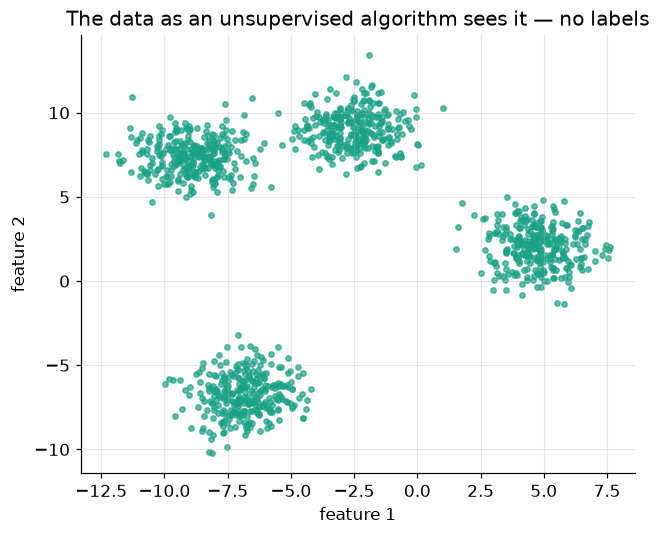

In [2]:
TRUE_K = 4          # the number of clusters we are about to create — the answer we hope to recover
N_SAMPLES = 1200

X, y_true = make_blobs(
    n_samples=N_SAMPLES,
    centers=TRUE_K,
    n_features=2,      # 2 features so we can simply plot the data and look at it
    cluster_std=1.15,  # how wide each blob is; larger = more overlap = harder problem
    random_state=SEED,
)

print(f'X shape: {X.shape}   (rows = points, columns = features)')
print(f'True cluster sizes: {np.bincount(y_true)}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=12, c=TEAL, alpha=0.7)
ax.set_title('The data as an unsupervised algorithm sees it — no labels')
ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')
plt.tight_layout(); plt.show()

Look at that plot the way an algorithm does. There are no colours, no labels, no target column —
just 1,200 points in a plane. Your eye says "four groups". Our job for the rest of the notebook is
to make that judgement something a machine can make, and defend.

We do hold `y_true` in a variable, but treat it as **locked away**. We only unlock it in Part 1 to
demonstrate what external validation would look like if you were lucky enough to have labels.

---
## Part 1: Why accuracy does not apply

### 1.1 Cluster labels are arbitrary names

Here is the first trap. K-Means returns an integer for each point: 0, 1, 2, 3. It is tempting to
compare those integers with the true labels and count matches. That comparison is meaningless,
because the numbers are **arbitrary names**, not predictions. The same clustering, run again with a
different seed, might call the top-left group "2" instead of "0" — an identical result that scores
completely differently.

In [3]:
km = KMeans(n_clusters=TRUE_K, n_init=10, random_state=SEED).fit(X)
pred = km.labels_

# The naive (and wrong) approach: treat cluster ids as if they were class predictions.
naive_accuracy = np.mean(pred == y_true)
print(f'Naive "accuracy" comparing cluster ids to true labels: {naive_accuracy:.3f}')

# Now permute the cluster names. Nothing about the grouping changes — the same points
# are still together — but the naive score moves all over the place.
rng = np.random.default_rng(SEED)
print('\nSame clustering, cluster ids renamed at random:')
for trial in range(5):
    mapping = rng.permutation(TRUE_K)      # e.g. [2, 0, 3, 1]: cluster 0 is now called 2, etc.
    renamed = mapping[pred]
    print(f'  permutation {mapping} -> naive "accuracy" = {np.mean(renamed == y_true):.3f}')

print('\nThe grouping never changed. Only the names did.')
print('A score that moves when you rename things is not measuring the thing you care about.')

Naive "accuracy" comparing cluster ids to true labels: 0.501

Same clustering, cluster ids renamed at random:
  permutation [3 2 1 0] -> naive "accuracy" = 0.499
  permutation [3 2 0 1] -> naive "accuracy" = 0.250
  permutation [0 3 2 1] -> naive "accuracy" = 0.251
  permutation [2 3 0 1] -> naive "accuracy" = 0.000
  permutation [2 3 0 1] -> naive "accuracy" = 0.000

The grouping never changed. Only the names did.
A score that moves when you rename things is not measuring the thing you care about.


This is why the lecture says accuracy does not apply. What we actually want to measure is
**agreement between two partitions**, independent of what the groups are called. `adjusted_rand_score`
does exactly that: it asks, for every pair of points, whether the two partitions agree about
*whether that pair belongs together*. Pair membership survives renaming.

In [4]:
print('Adjusted Rand Index (ARI) is immune to renaming:')
for trial in range(3):
    mapping = rng.permutation(TRUE_K)
    print(f'  permutation {mapping} -> ARI = {adjusted_rand_score(y_true, mapping[pred]):.3f}')

print('\nARI scale:  1.0 = identical partitions   0.0 = no better than random   <0 = worse than random')

Adjusted Rand Index (ARI) is immune to renaming:
  permutation [1 0 2 3] -> ARI = 0.998
  permutation [0 2 3 1] -> ARI = 0.998
  permutation [1 0 2 3] -> ARI = 0.998

ARI scale:  1.0 = identical partitions   0.0 = no better than random   <0 = worse than random


### 1.2 The three families of validation

With accuracy ruled out, three options remain. The whole of Part 2 onwards is really about the
first one, because it is the only family that is always available.

In [5]:
# --- INTERNAL: uses only the data and the fitted model. Always available.
internal = silhouette_score(X, pred)

# --- EXTERNAL: compares against labels you held back. Only possible if labels exist.
external = adjusted_rand_score(y_true, pred)
external_nmi = normalized_mutual_info_score(y_true, pred)

# --- DOWNSTREAM: does the clustering improve the task you actually care about?
#     Sketched here as: how much of the variance in the data do the cluster means explain?
#     (In a real project this would be a classifier's accuracy, revenue per segment, and so on.)
total_variance = np.sum((X - X.mean(axis=0)) ** 2)
unexplained = km.inertia_
downstream = 1 - unexplained / total_variance

print(f'INTERNAL    silhouette                 = {internal:.3f}   (higher is better, max 1)')
print(f'EXTERNAL    adjusted Rand index        = {external:.3f}   (needs held-back labels)')
print(f'EXTERNAL    normalised mutual info     = {external_nmi:.3f}')
print(f'DOWNSTREAM  variance explained by k=4  = {downstream:.3f}   (stand-in for a real task)')

INTERNAL    silhouette                 = 0.763   (higher is better, max 1)
EXTERNAL    adjusted Rand index        = 0.998   (needs held-back labels)
EXTERNAL    normalised mutual info     = 0.996
DOWNSTREAM  variance explained by k=4  = 0.962   (stand-in for a real task)


> **Try this.** Rerun the two cells above with `TRUE_K` clusters replaced by 7 in the `KMeans` call.
> Watch the external score collapse while the internal score only sags. Internal metrics are more
> forgiving than the truth — worth remembering before you trust one on its own.

---
## Part 2: Internal metrics: what each one rewards

### 2.1 Inertia falls forever, so it cannot choose k

Inertia is the total squared distance from each point to its own cluster centre. Adding a cluster
can only ever reduce it — in the limit, every point becomes its own cluster and inertia hits zero.

A metric that always improves as the model grows **cannot be used to select model size**. This is
the single most common mistake students make with K-Means.

In [6]:
k_range = range(2, 11)

inertias, silhouettes, davies_bouldins = [], [], []

for k in k_range:
    # n_init=10 runs K-Means from 10 different random starts and keeps the best,
    # which protects us against a single unlucky initialisation.
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    labels = model.labels_

    inertias.append(model.inertia_)                        # lower is better, but always falls
    silhouettes.append(silhouette_score(X, labels))        # higher is better, has a real maximum
    davies_bouldins.append(davies_bouldin_score(X, labels))  # lower is better

print(f'{"k":>3}  {"inertia":>10}  {"silhouette":>11}  {"Davies-Bouldin":>15}')
for k, i, s, d in zip(k_range, inertias, silhouettes, davies_bouldins):
    print(f'{k:>3}  {i:>10.1f}  {s:>11.3f}  {d:>15.3f}')

  k     inertia   silhouette   Davies-Bouldin
  2     39144.6        0.579            0.547
  3      9626.9        0.735            0.380
  4      3068.6        0.763            0.330
  5      2776.7        0.634            0.683
  6      2490.9        0.517            0.912
  7      2239.7        0.419            1.066
  8      1978.3        0.328            1.177
  9      1800.3        0.338            1.070
 10      1652.8        0.335            1.014


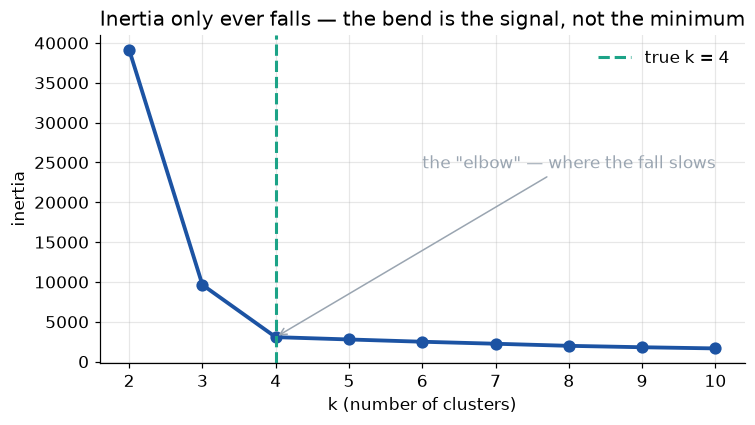

Note that inertia at k=10 is the *best* value on the chart.
If you selected k by minimising inertia you would always pick the largest k you tried.


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, 'o-', color=BLUE, linewidth=2.5, markersize=7)
ax.axvline(TRUE_K, color=TEAL, linestyle='--', linewidth=2, label=f'true k = {TRUE_K}')
ax.annotate('the "elbow" — where the fall slows',
            xy=(TRUE_K, inertias[TRUE_K - 2]), xytext=(6.0, inertias[0] * 0.62),
            arrowprops=dict(arrowstyle='->', color=GREY), color=GREY)
ax.set_xlabel('k (number of clusters)'); ax.set_ylabel('inertia')
ax.set_title('Inertia only ever falls — the bend is the signal, not the minimum')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print('Note that inertia at k=10 is the *best* value on the chart.')
print('If you selected k by minimising inertia you would always pick the largest k you tried.')

### 2.2 Silhouette has a genuine maximum, so it *can* choose k

Silhouette works differently. For each point it compares two distances:

- **a**: the mean distance to the other points in its *own* cluster (how cohesive)
- **b**: the mean distance to the points in the *nearest other* cluster (how separated)

and scores that point as `(b - a) / max(a, b)`. The result runs from -1 (this point is closer to a
different cluster — it is probably misassigned) through 0 (on the boundary) to +1 (comfortably
inside its own cluster).

Split a real cluster in two and every point in it gets a *worse* score, because a neighbouring
cluster is now very close by. That is what gives silhouette a maximum — and a maximum is what you
need in order to choose.

**This cell reproduces the bar chart on slide 7 of the lecture.**

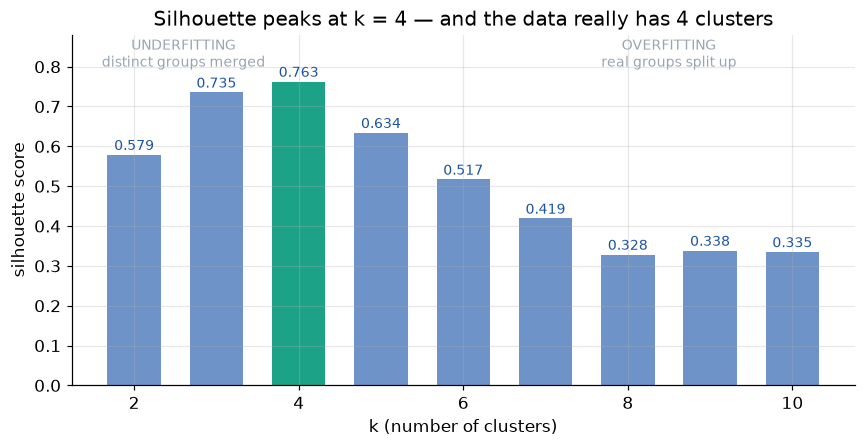

Silhouette chose k = 4.  True k = 4.  Correct.


In [8]:
best_k = list(k_range)[int(np.argmax(silhouettes))]

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [TEAL if k == best_k else PALE for k in k_range]
bars = ax.bar(list(k_range), silhouettes, color=colors, width=0.65)

for k, s in zip(k_range, silhouettes):
    ax.text(k, s + 0.012, f'{s:.3f}', ha='center', fontsize=9, color=BLUE)

ax.set_xlabel('k (number of clusters)'); ax.set_ylabel('silhouette score')
ax.set_ylim(0, 0.88)
ax.set_title(f'Silhouette peaks at k = {best_k} — and the data really has {TRUE_K} clusters')
ax.text(2.6, 0.80, 'UNDERFITTING\ndistinct groups merged', fontsize=9, color=GREY, ha='center')
ax.text(8.5, 0.80, 'OVERFITTING\nreal groups split up', fontsize=9, color=GREY, ha='center')
plt.tight_layout(); plt.show()

print(f'Silhouette chose k = {best_k}.  True k = {TRUE_K}.  {"Correct." if best_k == TRUE_K else "Missed."}')

### 2.3 Looking inside the score: the silhouette diagram

The single number hides useful detail. Plotting every point's individual silhouette, grouped by
cluster, shows *which* clusters are solid and which are marginal. A well-chosen k gives blocks of
similar width that mostly sit to the right of the average line; a bad k gives ragged blocks and
points below zero.

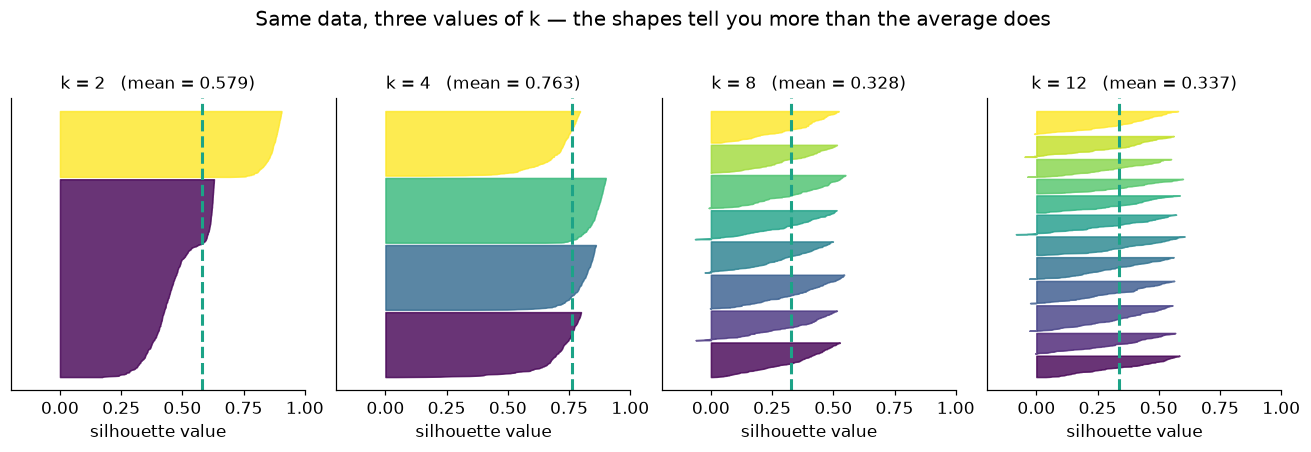

In [9]:
def silhouette_diagram(X, k, ax):
    '''Draw the per-point silhouette profile for a given k.'''
    labels = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X)
    values = silhouette_samples(X, labels)   # one score per point, not one per dataset
    mean_score = values.mean()

    y_lower = 10
    for i in range(k):
        # Sorting within each cluster is what produces the characteristic knife shapes.
        cluster_values = np.sort(values[labels == i])
        y_upper = y_lower + len(cluster_values)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                         color=plt.cm.viridis(i / max(k - 1, 1)), alpha=0.8)
        y_lower = y_upper + 10

    ax.axvline(mean_score, color=TEAL, linestyle='--', linewidth=2)
    ax.set_title(f'k = {k}   (mean = {mean_score:.3f})', fontsize=11)
    ax.set_xlabel('silhouette value'); ax.set_yticks([])
    ax.set_xlim(-0.2, 1.0)
    ax.grid(False)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, k in zip(axes, [2, 4, 8, 12]):
    silhouette_diagram(X, k, ax)
plt.suptitle('Same data, three values of k — the shapes tell you more than the average does', y=1.02)
plt.tight_layout(); plt.show()

Read those three panels left to right:

- **k = 2** two huge blocks. Nothing scores badly, but we have merged genuinely distinct groups.
  This is underfitting, and note that it looks *reassuring*: no negative values, no obvious fault.
- **k = 4** four blocks of similar width, all comfortably past the mean line. This is what a
  correct k looks like.
- **k = 8** narrow, uneven blocks, several dipping towards or below zero. Real clusters have
  been split, so points now sit close to a "different" cluster that is really part of their own.

> **Try this.** Add `12` to the list and rerun. The fragmentation becomes obvious.

---
## Part 3: Stability: did we find structure, or fit noise?

A metric computed once on one dataset can be lucky. Structure that is really there will reappear
when you resample the data; structure you invented will not.

The test: draw many bootstrap samples, cluster each one, and measure how much the partitions agree
with each other using ARI. High agreement means the structure is a property of the data. Low
agreement means it is a property of the particular sample you happened to have.

In [10]:
def stability(X, k, n_trials=12, sample_frac=0.8, seed=SEED):
    '''
    Cluster many overlapping subsamples, then measure how much the resulting
    partitions agree on the points that any two subsamples share.

    Returns the mean pairwise ARI: 1.0 = perfectly reproducible, 0.0 = arbitrary.
    '''
    rng = np.random.default_rng(seed)
    n_sub = int(len(X) * sample_frac)

    # Store, for each trial, which original points were used and what label each got.
    runs = []
    for t in range(n_trials):
        idx = rng.choice(len(X), size=n_sub, replace=False)
        labels = KMeans(n_clusters=k, n_init=10, random_state=int(rng.integers(1e6))).fit_predict(X[idx])
        assignment = np.full(len(X), -1)     # -1 marks "this point was not in this subsample"
        assignment[idx] = labels
        runs.append(assignment)

    # Compare every pair of runs, but only on the points that appear in both.
    scores = []
    for a in range(len(runs)):
        for b in range(a + 1, len(runs)):
            shared = (runs[a] >= 0) & (runs[b] >= 0)
            scores.append(adjusted_rand_score(runs[a][shared], runs[b][shared]))
    return float(np.mean(scores))

print(f'{"k":>3}  {"stability (mean pairwise ARI)":>30}')
stab = []
for k in k_range:
    s = stability(X, k)
    stab.append(s)
    flag = '  <-- most reproducible' if k == TRUE_K else ''
    print(f'{k:>3}  {s:>30.3f}{flag}')

  k   stability (mean pairwise ARI)
  2                           1.000
  3                           1.000
  4                           1.000  <-- most reproducible
  5                           0.925
  6                           0.831
  7                           0.774
  8                           0.790
  9                           0.777
 10                           0.727


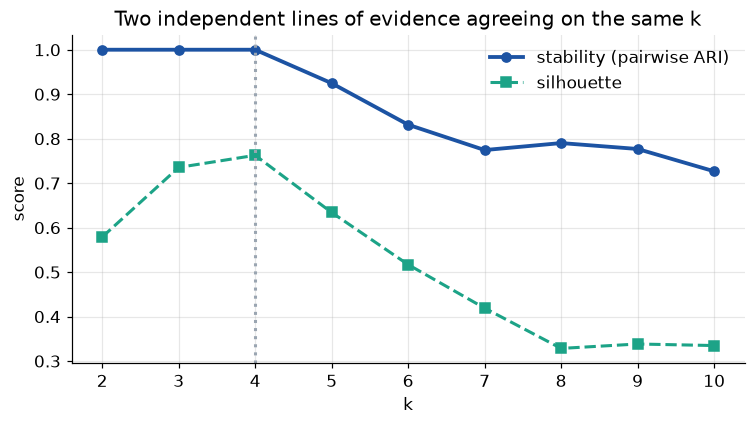

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), stab, 'o-', color=BLUE, linewidth=2.5, label='stability (pairwise ARI)')
ax.plot(list(k_range), silhouettes, 's--', color=TEAL, linewidth=2, label='silhouette')
ax.axvline(TRUE_K, color=GREY, linestyle=':', linewidth=2)
ax.set_xlabel('k'); ax.set_ylabel('score')
ax.set_title('Two independent lines of evidence agreeing on the same k')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

Two different criteria: one geometric, one about reproducibility; pointing at the same k is a far
stronger argument than either alone. When they disagree, that disagreement is itself the finding,
and it usually means the clusters overlap.

### Seeds and local optima

K-Means does not find the global optimum. It converges to a local one that depends on where the
centres start. `n_init` hides this by running several starts and keeping the best, but it is worth
seeing the variation you are being protected from.

In [12]:
# n_init=1 deliberately disables the protection so we can see raw run-to-run variation.
solutions = []
for seed in range(8):
    m = KMeans(n_clusters=8, n_init=1, random_state=seed).fit(X)
    solutions.append((seed, m.inertia_, m.labels_))

print('k = 8, a single random start each time:')
for seed, inertia, _ in solutions:
    print(f'  seed {seed}: inertia = {inertia:8.1f}')

spread = max(s[1] for s in solutions) - min(s[1] for s in solutions)
print(f'\nSpread between best and worst run: {spread:.1f}')
print('Agreement between the first two runs (ARI):'
      f' {adjusted_rand_score(solutions[0][2], solutions[1][2]):.3f}')
print('\nSame algorithm, same data, same k — different answers. Always report which you used.')

k = 8, a single random start each time:
  seed 0: inertia =   2122.7
  seed 1: inertia =   2307.1
  seed 2: inertia =   2088.4
  seed 3: inertia =   2110.0
  seed 4: inertia =   2105.1
  seed 5: inertia =   2120.8
  seed 6: inertia =   2098.8
  seed 7: inertia =   2132.6

Spread between best and worst run: 218.8
Agreement between the first two runs (ARI): 0.692

Same algorithm, same data, same k — different answers. Always report which you used.


---
## Part 4: Overfitting and underfitting without labels

### 4.1 What it looks like

Before any metric, look at the failure directly. Three fits of the same data: too few clusters,
the right number, far too many.

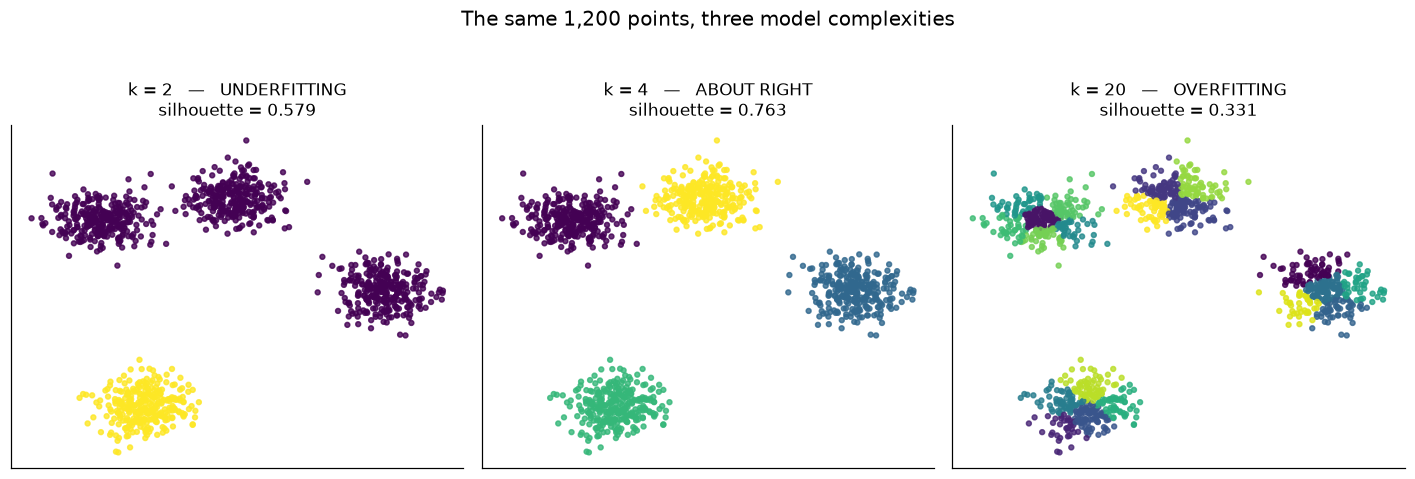

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

for ax, k, verdict in zip(axes, [2, 4, 20],
                          ['UNDERFITTING', 'ABOUT RIGHT', 'OVERFITTING']):
    labels = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10, alpha=0.8)
    ax.set_title(f'k = {k}   —   {verdict}\nsilhouette = {silhouette_score(X, labels):.3f}',
                 fontsize=11)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

plt.suptitle('The same 1,200 points, three model complexities', y=1.03)
plt.tight_layout(); plt.show()

The middle panel recovers the structure. The left one merges two genuinely different groups into
one. The right one carves each real group into arbitrary slices — and here is the important part:
**those slice boundaries are not properties of the data**. Draw a fresh sample from the same source
and they would land somewhere else entirely. That is what overfitting means when there are no
labels: describing accidents of this particular sample as though they were structure.

### 4.2 Watching a model overfit, measured

K-Means makes the point visually but cannot quite prove it, because inertia has no held-out
equivalent that penalises complexity. A **Gaussian Mixture Model** can, because it is a proper
probability model: it assigns a likelihood to any point, including points it has never seen.

So we can do the supervised thing after all — fit on one split, score on another:

- **Training log-likelihood** rises without limit as we add components. More components can always
  describe the training data better.
- **Held-out log-likelihood** rises while the extra components capture real structure, then falls
  once they start describing training noise.

The gap between those two curves *is* overfitting, made visible without a single label.

**This cell reproduces the line chart on slide 13 of the lecture.**

In [14]:
# A genuine train/test split — the same discipline as supervised learning,
# except that what we score is likelihood rather than accuracy.
X_train, X_test = train_test_split(X, test_size=0.35, random_state=SEED)
print(f'train: {X_train.shape[0]} points     held-out: {X_test.shape[0]} points')

component_counts = [1, 2, 4, 8, 16, 32, 64]
train_ll, test_ll = [], []

for n_components in component_counts:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=SEED,
        reg_covar=1e-4,   # keeps covariance matrices invertible when a component gets tiny
    ).fit(X_train)

    # .score() returns the MEAN log-likelihood per sample, so the two splits are comparable
    # despite having different numbers of points.
    train_ll.append(gmm.score(X_train))
    test_ll.append(gmm.score(X_test))

print(f'\n{"components":>11}  {"train":>9}  {"held-out":>9}  {"gap":>7}')
for n, a, b in zip(component_counts, train_ll, test_ll):
    print(f'{n:>11}  {a:>9.3f}  {b:>9.3f}  {a - b:>7.3f}')

best_n = component_counts[int(np.argmax(test_ll))]
print(f'\nHeld-out likelihood peaks at {best_n} components. True number of groups: {TRUE_K}.')

train: 780 points     held-out: 420 points

 components      train   held-out      gap
          1     -6.360     -6.330   -0.031
          2     -5.360     -5.452    0.092
          4     -4.451     -4.499    0.049
          8     -4.448     -4.526    0.078
         16     -4.418     -4.546    0.128
         32     -4.320     -4.652    0.332
         64     -4.161     -4.924    0.763

Held-out likelihood peaks at 4 components. True number of groups: 4.


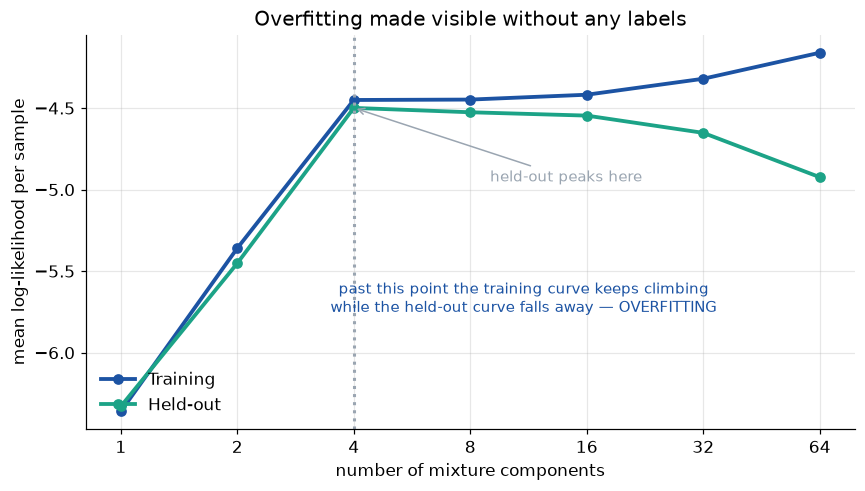

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(component_counts, train_ll, 'o-', color=BLUE, linewidth=2.5, label='Training')
ax.plot(component_counts, test_ll, 'o-', color=TEAL, linewidth=2.5, label='Held-out')

ax.axvline(best_n, color=GREY, linestyle=':', linewidth=2)
ax.annotate('held-out peaks here', xy=(best_n, max(test_ll)), xytext=(9, -4.95),
            arrowprops=dict(arrowstyle='->', color=GREY), color=GREY, fontsize=10)
ax.annotate('past this point the training curve keeps climbing\nwhile the held-out curve falls away — OVERFITTING',
            xy=(11, -5.75), color=BLUE, fontsize=10, ha='center')

ax.set_xscale('log', base=2)
ax.set_xticks(component_counts); ax.set_xticklabels(component_counts)
ax.set_xlabel('number of mixture components'); ax.set_ylabel('mean log-likelihood per sample')
ax.set_title('Overfitting made visible without any labels')
ax.legend(frameon=False, loc='lower left')
plt.tight_layout(); plt.show()

Read the shape, not the numbers. Up to four components the two curves climb together — the model is
learning things that are true of the data in general. After four they separate: the blue line keeps
rising because a 64-component mixture can wrap itself around individual training points, and the
green line falls because none of that detail transfers to data the model has not seen.

### 4.3 BIC: the same judgement, without a split

When data is scarce you may not want to give a third of it away. Information criteria such as
**BIC** approximate the same trade-off analytically, by taking the training likelihood and
subtracting a penalty that grows with the number of parameters. Lower BIC is better.

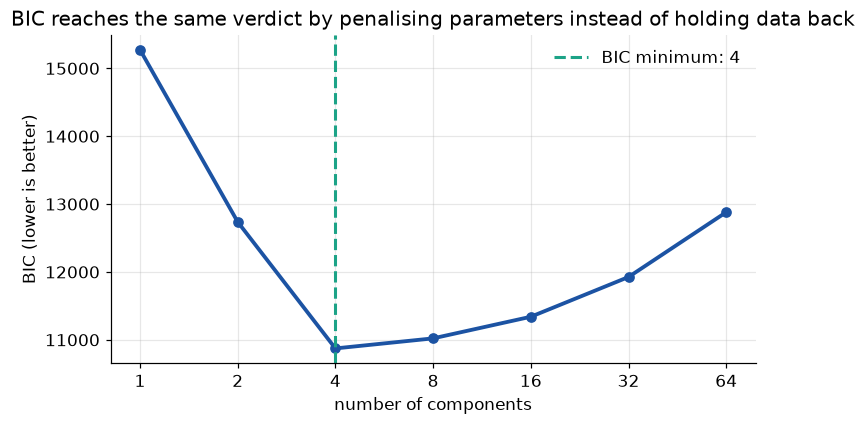

Held-out likelihood chose: 4 components
BIC chose:                 4 components
Truth:                     4 groups


In [16]:
bics = []
for n_components in component_counts:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full',
                          random_state=SEED, reg_covar=1e-4).fit(X)
    bics.append(gmm.bic(X))     # note: fitted on ALL the data — no split needed

best_bic_n = component_counts[int(np.argmin(bics))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(component_counts, bics, 'o-', color=BLUE, linewidth=2.5)
ax.axvline(best_bic_n, color=TEAL, linestyle='--', linewidth=2, label=f'BIC minimum: {best_bic_n}')
ax.set_xscale('log', base=2); ax.set_xticks(component_counts); ax.set_xticklabels(component_counts)
ax.set_xlabel('number of components'); ax.set_ylabel('BIC (lower is better)')
ax.set_title('BIC reaches the same verdict by penalising parameters instead of holding data back')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f'Held-out likelihood chose: {best_n} components')
print(f'BIC chose:                 {best_bic_n} components')
print(f'Truth:                     {TRUE_K} groups')

---
## Part 5: The complexity dial in other model families

Every unsupervised method has a knob that controls how much structure it is allowed to invent. It
is not always called `k`.

### 5.1 DBSCAN: `eps` is the dial

DBSCAN has no `k` at all. Instead, `eps` sets how close two points must be to count as neighbours.
Too small and every point is isolated, so everything is labelled noise. Too large and the whole
dataset merges into one blob. The useful range sits between those failures — and, as with `k`,
both failure modes are visible in the numbers.

In [17]:
eps_values = [0.15, 0.30, 0.50, 0.80, 1.20, 2.00, 3.00, 5.00]

print(f'{"eps":>6}  {"clusters":>9}  {"noise %":>8}   verdict')
for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=8).fit_predict(X)
    # DBSCAN marks noise as -1, so exclude it when counting clusters.
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = 100 * np.mean(labels == -1)

    if noise_pct > 40:
        verdict = 'eps too small — almost everything is "noise"'
    elif n_clusters > TRUE_K:
        verdict = 'fragmenting real groups (overfitting)'
    elif n_clusters < TRUE_K:
        verdict = 'groups merged together (underfitting)'
    else:
        verdict = 'recovers the true structure'
    print(f'{eps:>6.2f}  {n_clusters:>9}  {noise_pct:>8.1f}   {verdict}')

   eps   clusters   noise %   verdict
  0.15          1      99.3   eps too small — almost everything is "noise"
  0.30         14      47.2   eps too small — almost everything is "noise"
  0.50          4      12.6   recovers the true structure
  0.80          4       2.6   recovers the true structure
  1.20          3       0.2   groups merged together (underfitting)
  2.00          3       0.0   groups merged together (underfitting)
  3.00          2       0.0   groups merged together (underfitting)
  5.00          2       0.0   groups merged together (underfitting)


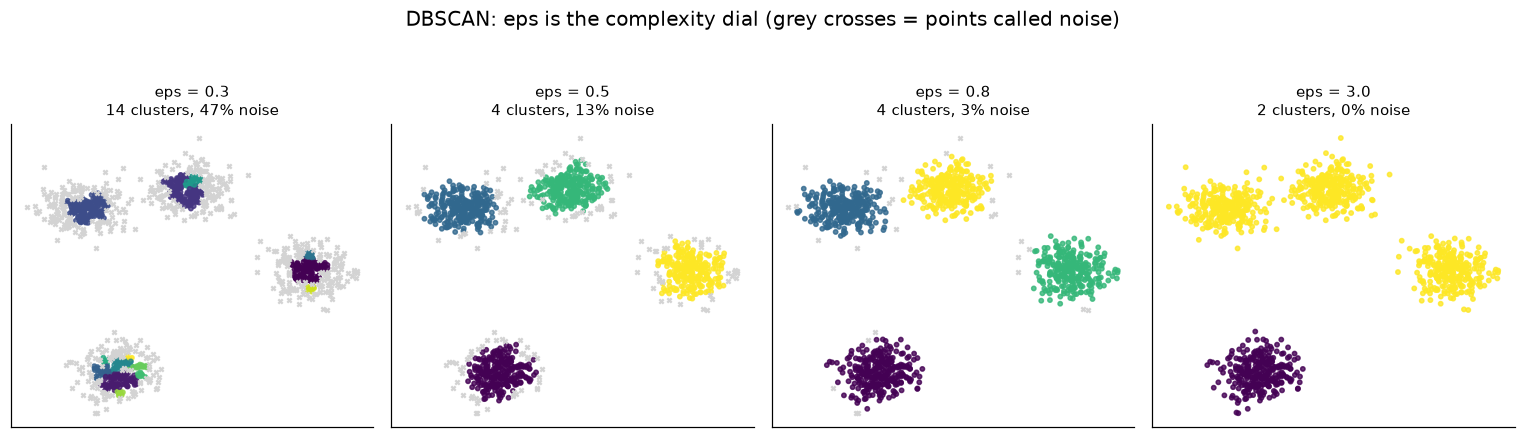

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, eps in zip(axes, [0.30, 0.50, 0.80, 3.00]):
    labels = DBSCAN(eps=eps, min_samples=8).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = labels == -1
    ax.scatter(X[~noise, 0], X[~noise, 1], c=labels[~noise], cmap='viridis', s=8, alpha=0.8)
    ax.scatter(X[noise, 0], X[noise, 1], c='lightgrey', s=8, marker='x')   # noise in grey
    ax.set_title(f'eps = {eps}\n{n_clusters} clusters, {100*noise.mean():.0f}% noise', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.suptitle('DBSCAN: eps is the complexity dial (grey crosses = points called noise)', y=1.04)
plt.tight_layout(); plt.show()

### 5.2 PCA: the number of components is the dial

This is the cleanest demonstration in the notebook, because we can construct data where we know
exactly how much real structure exists.

We build a dataset that is genuinely **rank 4**; every row is a combination of just four
underlying patterns, then add random noise on top. So the truth is: four components of signal,
and everything beyond that is noise.

Then we measure two different reconstruction errors, and they disagree in the most instructive way
possible:

- error against the **noisy input**; that you can actually measure in practice
- error against the **true clean signal**; what you would like to minimise, but normally cannot see

In [19]:
rng = np.random.default_rng(0)
n_rows, n_features, true_rank = 400, 60, 4

# Construct the clean signal: 400 rows, each a random combination of 4 underlying patterns.
patterns = rng.normal(size=(true_rank, n_features))     # the 4 real directions
weights = rng.normal(size=(n_rows, true_rank))          # how much of each pattern per row
clean = weights @ patterns                              # rank-4 by construction

# Corrupt it with noise. This is what a real dataset looks like: signal plus junk.
noisy = clean + rng.normal(scale=1.8, size=(n_rows, n_features))

train_idx, test_idx = train_test_split(np.arange(n_rows), test_size=0.4, random_state=0)

comps = [1, 2, 3, 4, 6, 8, 12, 20, 30, 40]
err_vs_noisy, err_vs_clean = [], []

for c in comps:
    pca = PCA(n_components=c, random_state=0).fit(noisy[train_idx])
    # Project held-out rows down to c dimensions and back up again.
    reconstructed = pca.inverse_transform(pca.transform(noisy[test_idx]))

    err_vs_noisy.append(np.mean((reconstructed - noisy[test_idx]) ** 2))
    err_vs_clean.append(np.mean((reconstructed - clean[test_idx]) ** 2))

print(f'{"components":>11}  {"error vs noisy input":>21}  {"error vs TRUE signal":>21}')
for c, a, b in zip(comps, err_vs_noisy, err_vs_clean):
    mark = '   <-- true rank' if c == true_rank else ''
    print(f'{c:>11}  {a:>21.3f}  {b:>21.3f}{mark}')

 components   error vs noisy input   error vs TRUE signal
          1                  5.647                  2.669
          2                  4.663                  1.769
          3                  3.802                  1.006
          4                  3.029                  0.292   <-- true rank
          6                  2.920                  0.395
          8                  2.813                  0.498
         12                  2.605                  0.696
         20                  2.160                  1.125
         30                  1.616                  1.638
         40                  1.067                  2.168


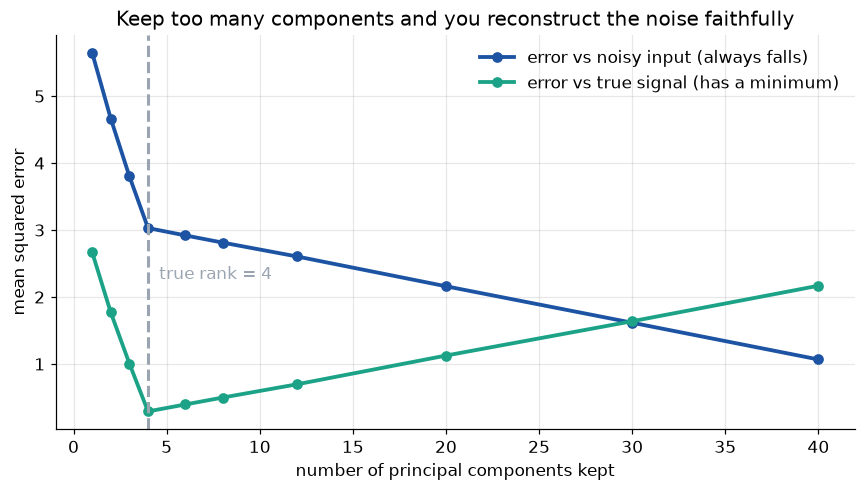

Error against the true signal is lowest at 4 components — exactly the rank we built in.


In [20]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(comps, err_vs_noisy, 'o-', color=BLUE, linewidth=2.5,
        label='error vs noisy input (always falls)')
ax.plot(comps, err_vs_clean, 'o-', color=TEAL, linewidth=2.5,
        label='error vs true signal (has a minimum)')
ax.axvline(true_rank, color=GREY, linestyle='--', linewidth=2)
ax.text(true_rank + 0.6, max(err_vs_clean) * 0.85, f'true rank = {true_rank}', color=GREY)
ax.set_xlabel('number of principal components kept'); ax.set_ylabel('mean squared error')
ax.set_title('Keep too many components and you reconstruct the noise faithfully')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f'Error against the true signal is lowest at {comps[int(np.argmin(err_vs_clean))]} components'
      f' — exactly the rank we built in.')

The blue line is what a practitioner can measure, and it falls forever reconstructing the input
always gets easier with more components, exactly like inertia. The green line is the truth, and it
has a clear minimum at 4.

Past 4 components, PCA is doing its job perfectly: it is reproducing the input as faithfully as it
can. The problem is that the input contains noise, so faithfulness becomes a fault. **This is
overfitting stated precisely**; and it is the same shape as the GMM curves in Part 4.

Since you normally cannot see the green line, you need one of the substitutes from Part 4: a
held-out score, an information criterion, or a scree plot with an elbow.

---
## Part 6: Fixing it

Four habits, each of which prevents a specific failure.

### 6.1 Scale your features first

Distance-based methods add up differences across features. If one feature is measured in thousands
and another in tenths, the first one silently decides every cluster. Standardising puts them on
equal footing.

Clustering the unscaled data — ARI vs truth: 0.773
Clustering after standardising  — ARI vs truth: 0.998


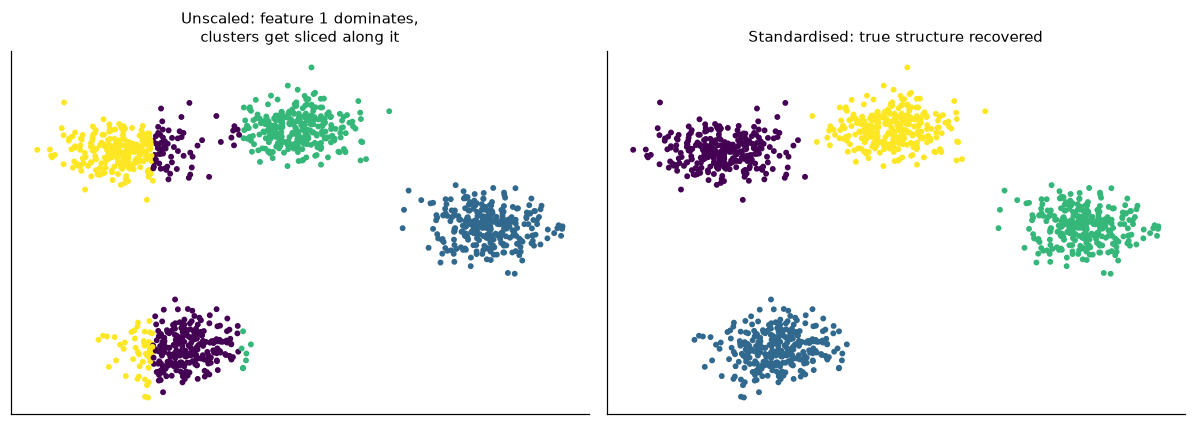

In [21]:
# Take our well-behaved data and stretch one feature by 100x —
# as if it had been recorded in centimetres instead of metres.
X_unscaled = X.copy()
X_unscaled[:, 0] *= 100

labels_raw = KMeans(n_clusters=TRUE_K, n_init=10, random_state=SEED).fit_predict(X_unscaled)

# StandardScaler subtracts the mean and divides by the standard deviation of each column,
# so every feature contributes on the same scale.
X_scaled = StandardScaler().fit_transform(X_unscaled)
labels_scaled = KMeans(n_clusters=TRUE_K, n_init=10, random_state=SEED).fit_predict(X_scaled)

print(f'Clustering the unscaled data — ARI vs truth: {adjusted_rand_score(y_true, labels_raw):.3f}')
print(f'Clustering after standardising  — ARI vs truth: {adjusted_rand_score(y_true, labels_scaled):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], c=labels_raw, cmap='viridis', s=8)
axes[0].set_title('Unscaled: feature 1 dominates,\nclusters get sliced along it', fontsize=10)
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_scaled, cmap='viridis', s=8)
axes[1].set_title('Standardised: true structure recovered', fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

### 6.2 Noise features manufacture false structure

Adding features that carry no signal does not leave the answer unchanged — it actively destroys it.
Distances get diluted across meaningless dimensions until real clusters stop looking separated.

In [22]:
rng = np.random.default_rng(SEED)

print(f'{"noise features added":>21}  {"silhouette":>11}  {"ARI vs truth":>13}')
for n_noise in [0, 2, 5, 10, 25, 50]:
    if n_noise == 0:
        X_aug = X
    else:
        # Pure random columns: no relationship to the clusters whatsoever.
        noise_cols = rng.normal(scale=X.std(), size=(len(X), n_noise))
        X_aug = np.hstack([X, noise_cols])

    labels = KMeans(n_clusters=TRUE_K, n_init=10, random_state=SEED).fit_predict(X_aug)
    print(f'{n_noise:>21}  {silhouette_score(X_aug, labels):>11.3f}'
          f'  {adjusted_rand_score(y_true, labels):>13.3f}')

print('\nSilhouette collapses along with the truth — here it is honestly reporting the damage.')
print('Feature selection is not just tidiness; it is a precondition for clustering to work.')

 noise features added   silhouette   ARI vs truth
                    0        0.763          0.998
                    2        0.291          0.639
                    5        0.134          0.649
                   10        0.068          0.340
                   25        0.027          0.007
                   50        0.015          0.003

Silhouette collapses along with the truth — here it is honestly reporting the damage.
Feature selection is not just tidiness; it is a precondition for clustering to work.


### 6.3 The checklist, as code

A function that applies everything above and reports a defensible choice of k rather than a bare
number.

One subtlety it has to handle. **Stability is biased towards small k**: two clusters are trivially
reproducible, so if you simply pick the k with the highest stability you will almost always be told
"2". Stability is therefore not a selector; it is a *filter*. Use it to rule out values of k that
do not survive resampling, then choose among the survivors with a metric that has a real maximum.
Getting this backwards is a common and quiet mistake.

In [23]:
STABILITY_FLOOR = 0.90   # below this, a partition is not reproducible enough to report

def choose_k(X, k_range=range(2, 11), seed=SEED, verbose=True):
    '''
    Select k using three criteria, used for what each is actually good for.

      silhouette      - has a real maximum, so it can SELECT k
      Davies-Bouldin  - has a real minimum, so it can SELECT k (second opinion)
      stability       - biased towards small k, so it can only FILTER k

    Agreement between the two selectors, within the range the filter allows,
    is the actual evidence. One metric pointing at a number is a suggestion.
    '''
    results = {}
    for k in k_range:
        labels = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X)
        results[k] = {
            'silhouette': silhouette_score(X, labels),            # higher better
            'davies_bouldin': davies_bouldin_score(X, labels),    # lower better
            'stability': stability(X, k, n_trials=8, seed=seed),  # higher better
        }

    # Step 1 — FILTER. Keep only the values of k that survive resampling.
    stable = [k for k in results if results[k]['stability'] >= STABILITY_FLOOR]
    if not stable:                      # nothing is reproducible: fall back to everything
        stable = list(results)

    # Step 2 — SELECT, but only from among the survivors.
    by_silhouette = max(stable, key=lambda k: results[k]['silhouette'])
    by_davies = min(stable, key=lambda k: results[k]['davies_bouldin'])

    if verbose:
        print(f'{"k":>3}  {"silhouette":>11}  {"Davies-Bouldin":>15}  {"stability":>10}  {"":>8}')
        for k, r in results.items():
            mark = 'stable' if r['stability'] >= STABILITY_FLOOR else ''
            print(f'{k:>3}  {r["silhouette"]:>11.3f}  {r["davies_bouldin"]:>15.3f}'
                  f'  {r["stability"]:>10.3f}  {mark:>8}')

        print(f'\n  FILTER    stability >= {STABILITY_FLOOR} keeps k in {stable}')
        print(f'            (note it keeps every small k — that is the bias, not a result)')
        print(f'  SELECT    silhouette peak within that range  -> k = {by_silhouette}')
        print(f'  SELECT    Davies-Bouldin minimum within it   -> k = {by_davies}')

        if by_silhouette == by_davies:
            print(f'\n  -> Both selectors agree on k = {by_silhouette}, and it is stable.')
        else:
            print(f'\n  -> Selectors disagree ({by_silhouette} vs {by_davies}).')
            print('     Report the range rather than a single number — this usually means')
            print('     the clusters overlap, and the choice of k is genuinely ambiguous.')

    return results

_ = choose_k(X)

  k   silhouette   Davies-Bouldin   stability          
  2        0.579            0.547       1.000    stable
  3        0.735            0.380       1.000    stable
  4        0.763            0.330       1.000    stable
  5        0.634            0.683       0.930    stable
  6        0.517            0.912       0.834          
  7        0.419            1.066       0.835          
  8        0.328            1.177       0.773          
  9        0.338            1.070       0.743          
 10        0.335            1.014       0.743          

  FILTER    stability >= 0.9 keeps k in [2, 3, 4, 5]
            (note it keeps every small k — that is the bias, not a result)
  SELECT    silhouette peak within that range  -> k = 4
  SELECT    Davies-Bouldin minimum within it   -> k = 4

  -> Both selectors agree on k = 4, and it is stable.


---
## Assignment

Work through these in order. Each one breaks something deliberately; the learning is in watching
which diagnostic notices first.

### Part 1: Make the problem harder

Regenerate the data with `cluster_std=2.5` instead of `1.15`, then rerun Part 2.

- Does silhouette still peak at 4?
- Does the peak get flatter? What does a flat peak mean about your confidence in k?
- At what `cluster_std` does the method stop recovering the truth?

### Part 2: Clusters of unequal size

`make_blobs` accepts a list for `cluster_std`, e.g. `[0.5, 0.5, 3.0, 0.5]`, giving one wide cluster
and three tight ones.

- What does K-Means do to the wide cluster, and why?
- Does DBSCAN handle it better? Why does the answer differ between the two?

### Part 3: When there is no structure at all

The most important negative result. Replace the data with pure noise:

```python
X_noise = np.random.default_rng(0).normal(size=(1200, 2))
```

- K-Means will still return clusters. What is the silhouette peak?
- Compare it to the ~0.76 we saw on real structure. Where would you set your own threshold for
  "this is probably not real"?
- What does the stability test say?

### Part 4: Find the elbow honestly

Write a function that locates the elbow of the inertia curve automatically, by finding the point
furthest from the straight line joining the first and last points of the curve.

- Does it agree with the silhouette peak on our data?
- Does it still agree on the harder data from Exercise 1?

### Part 5: Take it to real data

Load a dataset with no obvious answer key:

```python
from sklearn.datasets import load_wine
X_real = StandardScaler().fit_transform(load_wine().data)
```

Run `choose_k` on it. The true number of classes is 3, but do not look until you have committed to
an answer from the metrics alone. Then compare — and if you were wrong, work out which diagnostic
would have warned you.

---

## Summary

| Idea | Where it bites |
|---|---|
| Cluster labels are names, not predictions | Never compare them to truth directly; use ARI or NMI |
| Inertia always falls | It can never choose k on its own; read the elbow |
| Silhouette has a real maximum | It can choose k, and the peak has a defensible meaning |
| Stability separates structure from accident | Real groups survive resampling; invented ones do not |
| Overfitting = too much capacity | Not "test error goes up"; there is no test error |
| Held-out likelihood and BIC | The two honest ways to see it in mixture models |
| Every family has a complexity dial | `k`, `eps`, components retained, bottleneck width |
| Scale first, prune noise features | Both silently destroy clustering if ignored |
| Prefer the simpler model | When scores tie, fewer clusters generalises better and explains better |

The single sentence worth carrying out of this notebook: **a metric that improves every time you
add complexity cannot be used to choose complexity.** Inertia and reconstruction error both fail
this test. Silhouette, held-out likelihood, BIC, and stability all pass it.

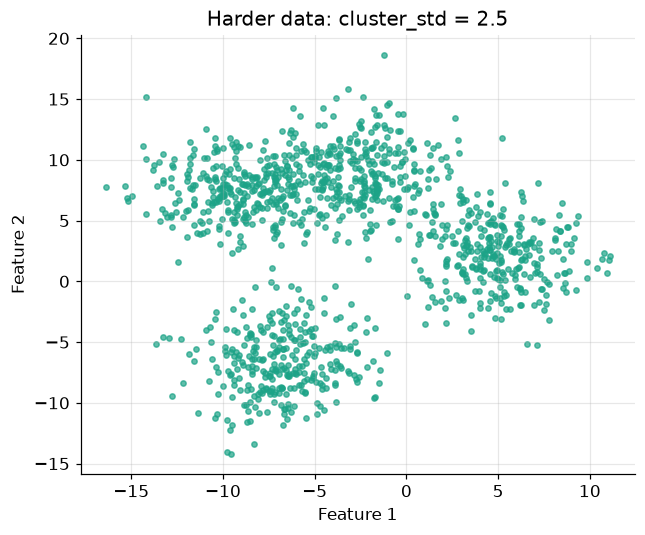

In [24]:
X_hard, y_hard = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=2.5,
    random_state=SEED,
)

plt.figure(figsize=(6, 5))
plt.scatter(X_hard[:, 0], X_hard[:, 1], s=12, alpha=0.7, color=TEAL)
plt.title("Harder data: cluster_std = 2.5")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [25]:
k_values = range(2, 11)
hard_silhouettes = []

for k in k_values:
    labels = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    ).fit_predict(X_hard)

    score = silhouette_score(X_hard, labels)
    hard_silhouettes.append(score)

for k, score in zip(k_values, hard_silhouettes):
    print(f"k={k:2d}  silhouette={score:.3f}")

k= 2  silhouette=0.483
k= 3  silhouette=0.579
k= 4  silhouette=0.533
k= 5  silhouette=0.475
k= 6  silhouette=0.402
k= 7  silhouette=0.332
k= 8  silhouette=0.332
k= 9  silhouette=0.329
k=10  silhouette=0.334


In [27]:
#assignment
X_hard, y_hard = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=2.5,
    random_state=SEED
)

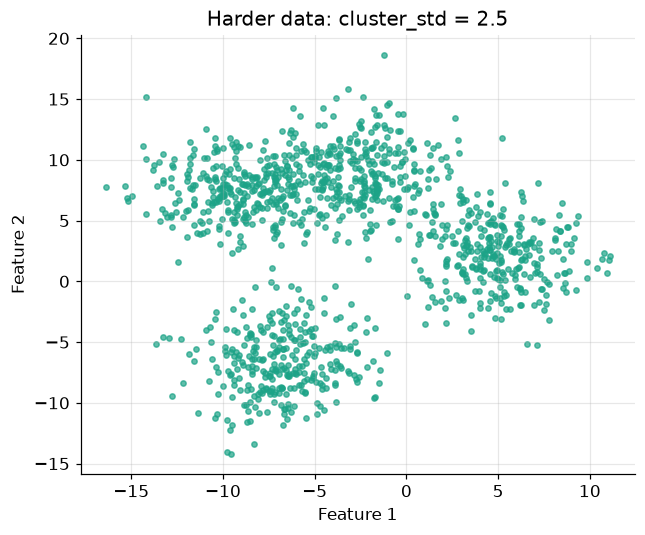

In [28]:
plt.figure(figsize=(6, 5))

plt.scatter(
    X_hard[:, 0],
    X_hard[:, 1],
    s=12,
    color=TEAL,
    alpha=0.7
)

plt.title("Harder data: cluster_std = 2.5")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [29]:
k_values = range(2, 11)
hard_silhouettes = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    )

    labels = model.fit_predict(X_hard)

    score = silhouette_score(X_hard, labels)
    hard_silhouettes.append(score)

    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.483
k=3, silhouette score=0.579
k=4, silhouette score=0.533
k=5, silhouette score=0.475
k=6, silhouette score=0.402
k=7, silhouette score=0.332
k=8, silhouette score=0.332
k=9, silhouette score=0.329
k=10, silhouette score=0.334


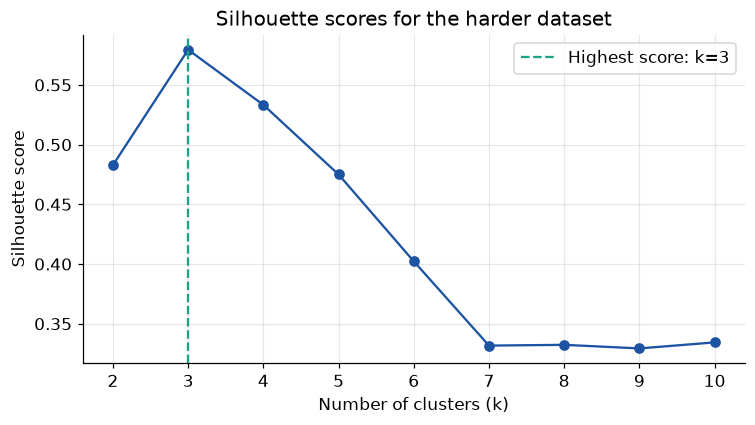

In [30]:
best_k_hard = list(k_values)[np.argmax(hard_silhouettes)]

plt.figure(figsize=(7, 4))

plt.plot(
    list(k_values),
    hard_silhouettes,
    marker="o",
    color=BLUE
)

plt.axvline(
    best_k_hard,
    color=TEAL,
    linestyle="--",
    label=f"Highest score: k={best_k_hard}"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores for the harder dataset")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
std_values = np.arange(1.0, 4.25, 0.25)

selected_k_values = []
highest_silhouette_scores = []

for std in std_values:
    X_temp, y_temp = make_blobs(
        n_samples=1200,
        centers=4,
        n_features=2,
        cluster_std=std,
        random_state=SEED
    )

    scores = []

    for k in range(2, 11):
        labels = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=SEED
        ).fit_predict(X_temp)

        score = silhouette_score(X_temp, labels)
        scores.append(score)

    selected_k = list(range(2, 11))[np.argmax(scores)]
    highest_score = max(scores)

    selected_k_values.append(selected_k)
    highest_silhouette_scores.append(highest_score)

    print(
        f"cluster_std={std:.2f}, "
        f"selected k={selected_k}, "
        f"highest silhouette={highest_score:.3f}"
    )

cluster_std=1.00, selected k=4, highest silhouette=0.793
cluster_std=1.25, selected k=4, highest silhouette=0.742
cluster_std=1.50, selected k=3, highest silhouette=0.695
cluster_std=1.75, selected k=3, highest silhouette=0.664
cluster_std=2.00, selected k=3, highest silhouette=0.636
cluster_std=2.25, selected k=3, highest silhouette=0.607
cluster_std=2.50, selected k=3, highest silhouette=0.579
cluster_std=2.75, selected k=3, highest silhouette=0.554
cluster_std=3.00, selected k=3, highest silhouette=0.529
cluster_std=3.25, selected k=3, highest silhouette=0.508
cluster_std=3.50, selected k=3, highest silhouette=0.489
cluster_std=3.75, selected k=3, highest silhouette=0.471
cluster_std=4.00, selected k=3, highest silhouette=0.454


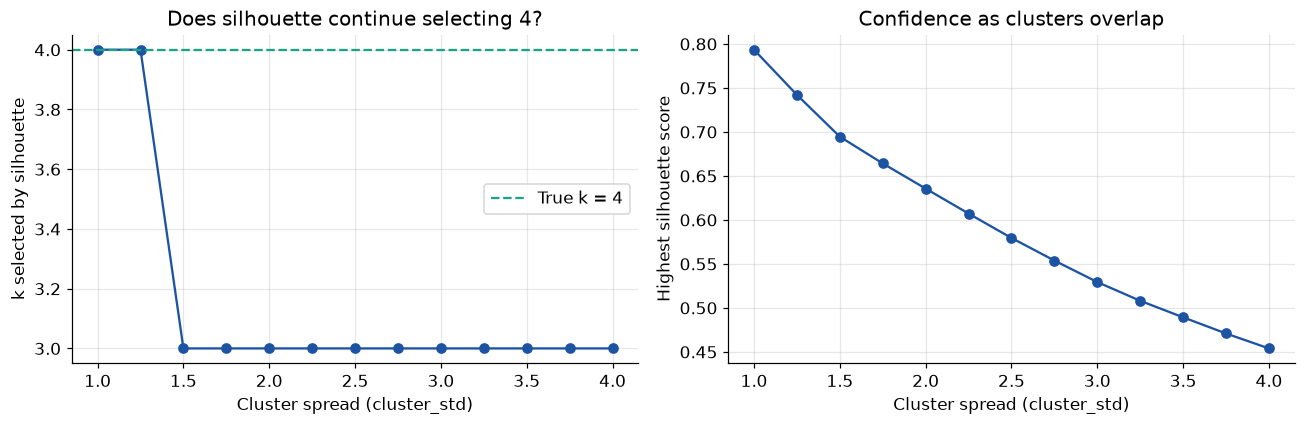

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left graph: which value of k silhouette selected
axes[0].plot(
    std_values,
    selected_k_values,
    marker="o",
    color=BLUE
)

axes[0].axhline(
    4,
    color=TEAL,
    linestyle="--",
    label="True k = 4"
)

axes[0].set_xlabel("Cluster spread (cluster_std)")
axes[0].set_ylabel("k selected by silhouette")
axes[0].set_title("Does silhouette continue selecting 4?")
axes[0].legend()

# Right graph: strength of the highest silhouette score
axes[1].plot(
    std_values,
    highest_silhouette_scores,
    marker="o",
    color=BLUE
)

axes[1].set_xlabel("Cluster spread (cluster_std)")
axes[1].set_ylabel("Highest silhouette score")
axes[1].set_title("Confidence as clusters overlap")

plt.tight_layout()
plt.show()

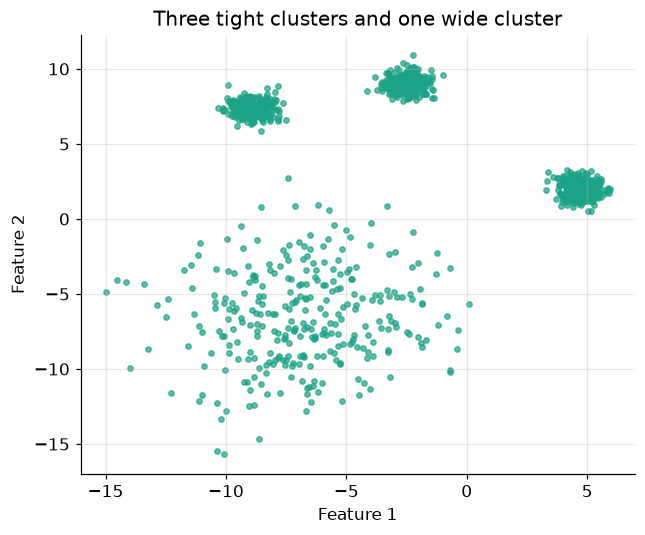

In [33]:
X_unequal, y_unequal = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=[0.5, 0.5, 3.0, 0.5],
    random_state=SEED
)

plt.figure(figsize=(6, 5))
plt.scatter(
    X_unequal[:, 0],
    X_unequal[:, 1],
    s=12,
    color=TEAL,
    alpha=0.7
)

plt.title("Three tight clusters and one wide cluster")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

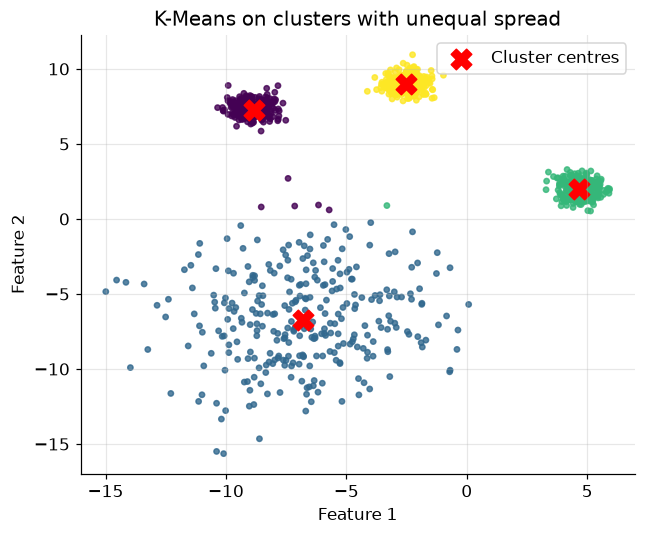

Silhouette: 0.8041014446540973
ARI: 0.9867490891791141


In [34]:
kmeans_unequal = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=SEED
)

kmeans_unequal_labels = kmeans_unequal.fit_predict(X_unequal)

plt.figure(figsize=(6, 5))

plt.scatter(
    X_unequal[:, 0],
    X_unequal[:, 1],
    c=kmeans_unequal_labels,
    cmap="viridis",
    s=12,
    alpha=0.8
)

plt.scatter(
    kmeans_unequal.cluster_centers_[:, 0],
    kmeans_unequal.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=180,
    label="Cluster centres"
)

plt.title("K-Means on clusters with unequal spread")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Silhouette:",
    silhouette_score(X_unequal, kmeans_unequal_labels)
)

print(
    "ARI:",
    adjusted_rand_score(y_unequal, kmeans_unequal_labels)
)

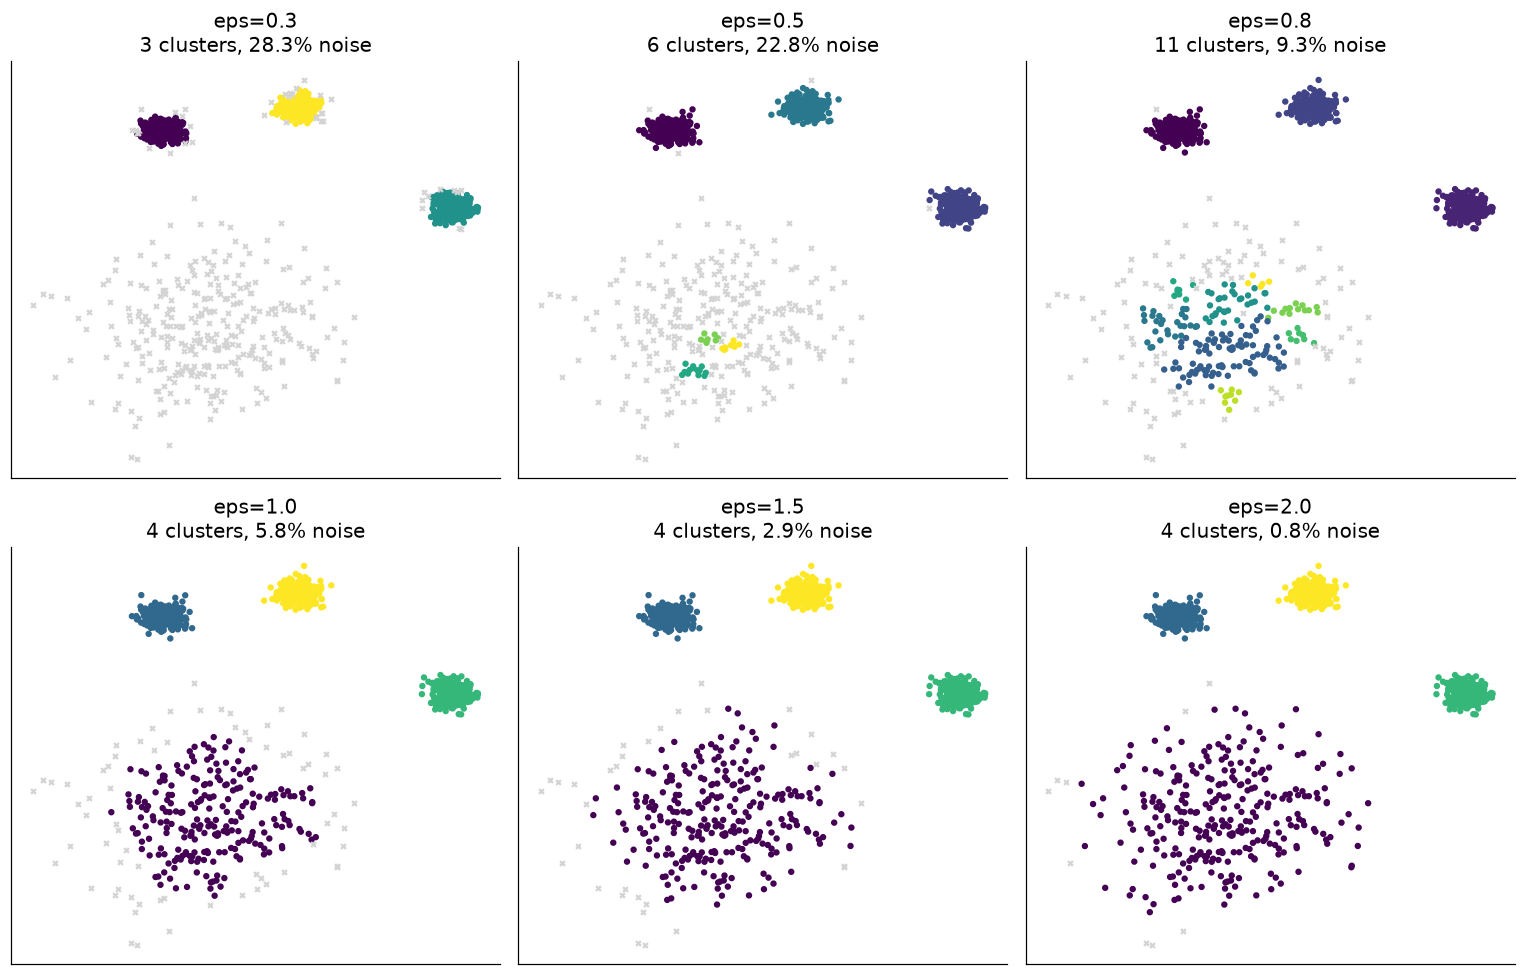

In [35]:
eps_values = [0.30, 0.50, 0.80, 1.00, 1.50, 2.00]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, eps in zip(axes.ravel(), eps_values):
    dbscan_labels = DBSCAN(
        eps=eps,
        min_samples=8
    ).fit_predict(X_unequal)

    noise = dbscan_labels == -1

    n_clusters = len(set(dbscan_labels))
    if -1 in dbscan_labels:
        n_clusters -= 1

    ax.scatter(
        X_unequal[~noise, 0],
        X_unequal[~noise, 1],
        c=dbscan_labels[~noise],
        cmap="viridis",
        s=10
    )

    ax.scatter(
        X_unequal[noise, 0],
        X_unequal[noise, 1],
        color="lightgrey",
        marker="x",
        s=10
    )

    ax.set_title(
        f"eps={eps}\n"
        f"{n_clusters} clusters, "
        f"{noise.mean() * 100:.1f}% noise"
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

plt.tight_layout()
plt.show()

In [36]:
print(f'{"eps":>6} {"clusters":>10} {"noise %":>10} {"ARI":>8}')

for eps in eps_values:
    labels = DBSCAN(
        eps=eps,
        min_samples=8
    ).fit_predict(X_unequal)

    n_clusters = len(set(labels))
    if -1 in labels:
        n_clusters -= 1

    noise_percentage = 100 * np.mean(labels == -1)
    ari = adjusted_rand_score(y_unequal, labels)

    print(
        f"{eps:>6.2f} "
        f"{n_clusters:>10} "
        f"{noise_percentage:>10.1f} "
        f"{ari:>8.3f}"
    )

   eps   clusters    noise %      ARI
  0.30          3       28.3    0.911
  0.50          6       22.8    0.960
  0.80         11        9.3    0.864
  1.00          4        5.8    0.939
  1.50          4        2.9    0.965
  2.00          4        0.8    0.990


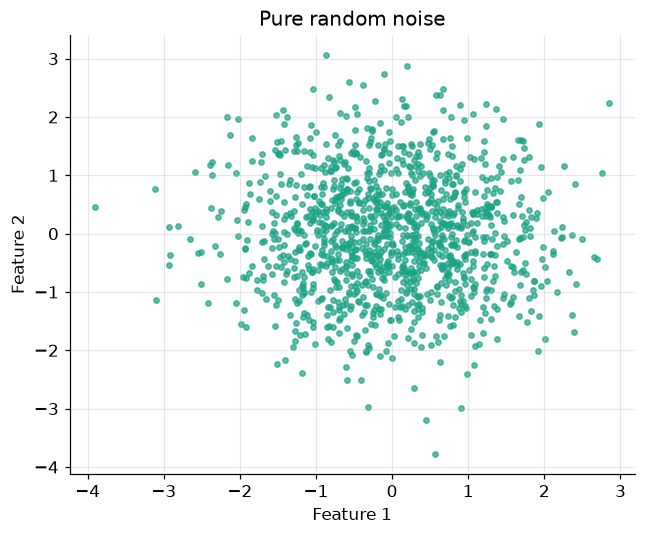

In [37]:
X_noise = np.random.default_rng(0).normal(
    size=(1200, 2)
)

plt.figure(figsize=(6, 5))

plt.scatter(
    X_noise[:, 0],
    X_noise[:, 1],
    s=12,
    color=TEAL,
    alpha=0.7
)

plt.title("Pure random noise")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

In [38]:
noise_k_values = list(range(2, 11))
noise_silhouettes = []

for k in noise_k_values:
    labels = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    ).fit_predict(X_noise)

    score = silhouette_score(X_noise, labels)
    noise_silhouettes.append(score)

    print(
        f"k={k}, silhouette score={score:.3f}"
    )

best_noise_k = noise_k_values[np.argmax(noise_silhouettes)]
best_noise_score = max(noise_silhouettes)

print()
print("Highest silhouette k:", best_noise_k)
print("Highest silhouette score:", round(best_noise_score, 3))

k=2, silhouette score=0.317
k=3, silhouette score=0.335
k=4, silhouette score=0.316
k=5, silhouette score=0.313
k=6, silhouette score=0.329
k=7, silhouette score=0.325
k=8, silhouette score=0.318
k=9, silhouette score=0.318
k=10, silhouette score=0.320

Highest silhouette k: 3
Highest silhouette score: 0.335


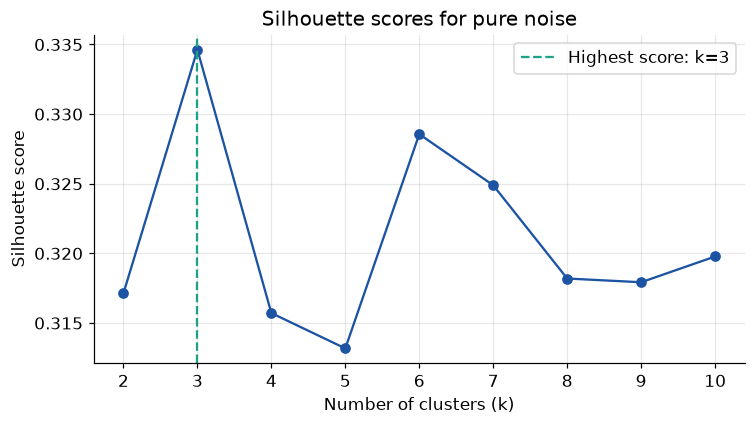

In [39]:
plt.figure(figsize=(7, 4))

plt.plot(
    noise_k_values,
    noise_silhouettes,
    marker="o",
    color=BLUE
)

plt.axvline(
    best_noise_k,
    color=TEAL,
    linestyle="--",
    label=f"Highest score: k={best_noise_k}"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores for pure noise")
plt.xticks(noise_k_values)
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
noise_stability = []

for k in noise_k_values:
    score = stability(
        X_noise,
        k=k,
        n_trials=12,
        sample_frac=0.8,
        seed=SEED
    )

    noise_stability.append(score)

    print(
        f"k={k}, stability={score:.3f}"
    )

k=2, stability=0.778
k=3, stability=0.681
k=4, stability=0.719
k=5, stability=0.547
k=6, stability=0.883
k=7, stability=0.716
k=8, stability=0.582
k=9, stability=0.592
k=10, stability=0.514


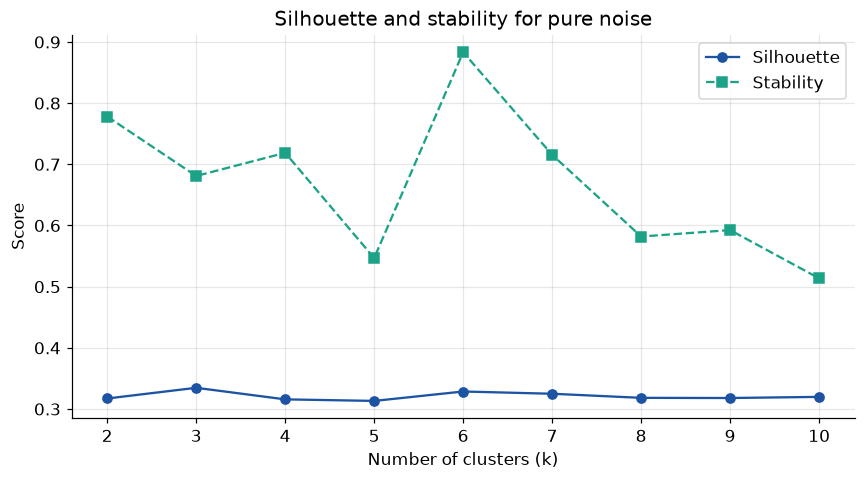

In [41]:
plt.figure(figsize=(8, 4.5))

plt.plot(
    noise_k_values,
    noise_silhouettes,
    marker="o",
    color=BLUE,
    label="Silhouette"
)

plt.plot(
    noise_k_values,
    noise_stability,
    marker="s",
    linestyle="--",
    color=TEAL,
    label="Stability"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Score")
plt.title("Silhouette and stability for pure noise")
plt.xticks(noise_k_values)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
def find_elbow(k_values, inertias):
    k_values = np.asarray(k_values, dtype=float)
    inertias = np.asarray(inertias, dtype=float)

    # Convert both axes to values between 0 and 1.
    normalized_k = (
        (k_values - k_values.min()) /
        (k_values.max() - k_values.min())
    )

    normalized_inertia = (
        (inertias - inertias.min()) /
        (inertias.max() - inertias.min())
    )

    points = np.column_stack([
        normalized_k,
        normalized_inertia
    ])

    first_point = points[0]
    last_point = points[-1]

    line_vector = last_point - first_point
    relative_points = points - first_point

    distances = np.abs(
        line_vector[0] * relative_points[:, 1]
        - line_vector[1] * relative_points[:, 0]
    ) / np.linalg.norm(line_vector)

    elbow_position = np.argmax(distances)
    elbow_k = int(k_values[elbow_position])

    return elbow_k, distances

In [43]:
elbow_k_values = list(range(2, 11))

original_inertias = []
original_silhouettes = []

for k in elbow_k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    )

    labels = model.fit_predict(X)

    original_inertias.append(model.inertia_)
    original_silhouettes.append(
        silhouette_score(X, labels)
    )

original_elbow_k, original_distances = find_elbow(
    elbow_k_values,
    original_inertias
)

original_silhouette_k = elbow_k_values[
    np.argmax(original_silhouettes)
]

print("Automatic elbow:", original_elbow_k)
print("Silhouette peak:", original_silhouette_k)

Automatic elbow: 4
Silhouette peak: 4


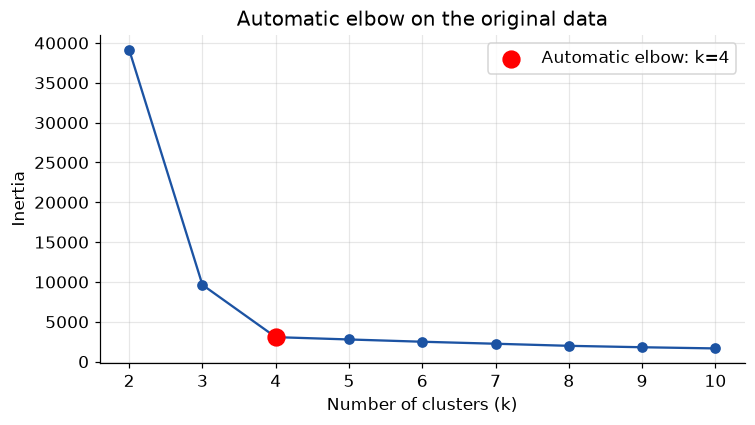

In [44]:
elbow_index = elbow_k_values.index(original_elbow_k)

plt.figure(figsize=(7, 4))

plt.plot(
    elbow_k_values,
    original_inertias,
    marker="o",
    color=BLUE
)

plt.scatter(
    original_elbow_k,
    original_inertias[elbow_index],
    color="red",
    s=120,
    label=f"Automatic elbow: k={original_elbow_k}",
    zorder=3
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Automatic elbow on the original data")
plt.xticks(elbow_k_values)
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
hard_inertias = []
hard_elbow_silhouettes = []

for k in elbow_k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    )

    labels = model.fit_predict(X_hard)

    hard_inertias.append(model.inertia_)
    hard_elbow_silhouettes.append(
        silhouette_score(X_hard, labels)
    )

hard_elbow_k, hard_distances = find_elbow(
    elbow_k_values,
    hard_inertias
)

hard_silhouette_k = elbow_k_values[
    np.argmax(hard_elbow_silhouettes)
]

print("Hard-data automatic elbow:", hard_elbow_k)
print("Hard-data silhouette peak:", hard_silhouette_k)

Hard-data automatic elbow: 4
Hard-data silhouette peak: 3


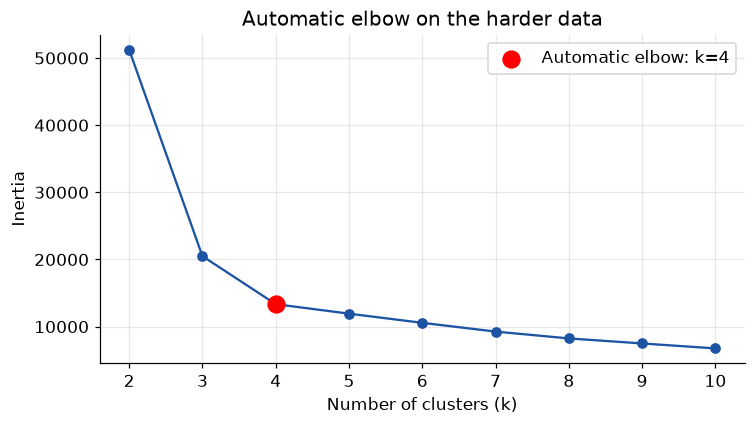

In [46]:
hard_elbow_index = elbow_k_values.index(hard_elbow_k)

plt.figure(figsize=(7, 4))

plt.plot(
    elbow_k_values,
    hard_inertias,
    marker="o",
    color=BLUE
)

plt.scatter(
    hard_elbow_k,
    hard_inertias[hard_elbow_index],
    color="red",
    s=120,
    label=f"Automatic elbow: k={hard_elbow_k}",
    zorder=3
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Automatic elbow on the harder data")
plt.xticks(elbow_k_values)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
from sklearn.datasets import load_wine

wine = load_wine()

X_real = StandardScaler().fit_transform(
    wine.data
)

print("Dataset shape:", X_real.shape)
print("Number of observations:", X_real.shape[0])
print("Number of features:", X_real.shape[1])

Dataset shape: (178, 13)
Number of observations: 178
Number of features: 13


In [48]:
wine_results = choose_k(
    X_real,
    k_range=range(2, 11),
    seed=SEED,
    verbose=True
)

  k   silhouette   Davies-Bouldin   stability          
  2        0.259            1.526       0.719          
  3        0.285            1.389       0.975    stable
  4        0.260            1.797       0.809          
  5        0.202            1.808       0.773          
  6        0.237            1.554       0.649          
  7        0.204            1.661       0.659          
  8        0.157            1.741       0.545          
  9        0.150            1.708       0.548          
 10        0.144            1.707       0.529          

  FILTER    stability >= 0.9 keeps k in [3]
            (note it keeps every small k — that is the bias, not a result)
  SELECT    silhouette peak within that range  -> k = 3
  SELECT    Davies-Bouldin minimum within it   -> k = 3

  -> Both selectors agree on k = 3, and it is stable.


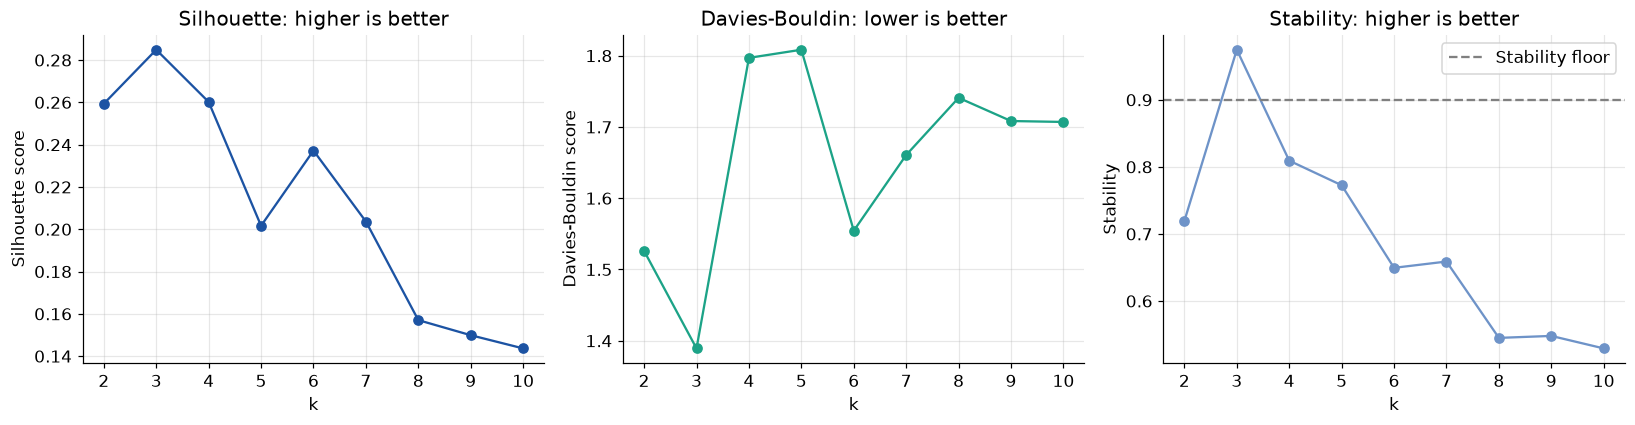

In [49]:
wine_k_values = list(wine_results.keys())

wine_silhouettes = [
    wine_results[k]["silhouette"]
    for k in wine_k_values
]

wine_davies_bouldin = [
    wine_results[k]["davies_bouldin"]
    for k in wine_k_values
]

wine_stabilities = [
    wine_results[k]["stability"]
    for k in wine_k_values
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

axes[0].plot(
    wine_k_values,
    wine_silhouettes,
    marker="o",
    color=BLUE
)
axes[0].set_title("Silhouette: higher is better")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette score")

axes[1].plot(
    wine_k_values,
    wine_davies_bouldin,
    marker="o",
    color=TEAL
)
axes[1].set_title("Davies-Bouldin: lower is better")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Davies-Bouldin score")

axes[2].plot(
    wine_k_values,
    wine_stabilities,
    marker="o",
    color=PALE
)
axes[2].axhline(
    STABILITY_FLOOR,
    color="grey",
    linestyle="--",
    label="Stability floor"
)
axes[2].set_title("Stability: higher is better")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Stability")
axes[2].legend()

plt.tight_layout()
plt.show()

In [50]:
y_real = wine.target

true_number_of_classes = len(np.unique(y_real))

print(
    "Number of classes in the hidden labels:",
    true_number_of_classes
)

Number of classes in the hidden labels: 3


In [51]:
my_k = 3  # Replace 3 with your own earlier choice.

wine_model = KMeans(
    n_clusters=my_k,
    n_init=10,
    random_state=SEED
)

wine_cluster_labels = wine_model.fit_predict(X_real)

wine_ari = adjusted_rand_score(
    y_real,
    wine_cluster_labels
)

wine_nmi = normalized_mutual_info_score(
    y_real,
    wine_cluster_labels
)

print(f"My selected k: {my_k}")
print(f"Hidden number of classes: {true_number_of_classes}")
print(f"ARI: {wine_ari:.3f}")
print(f"NMI: {wine_nmi:.3f}")

My selected k: 3
Hidden number of classes: 3
ARI: 0.897
NMI: 0.876


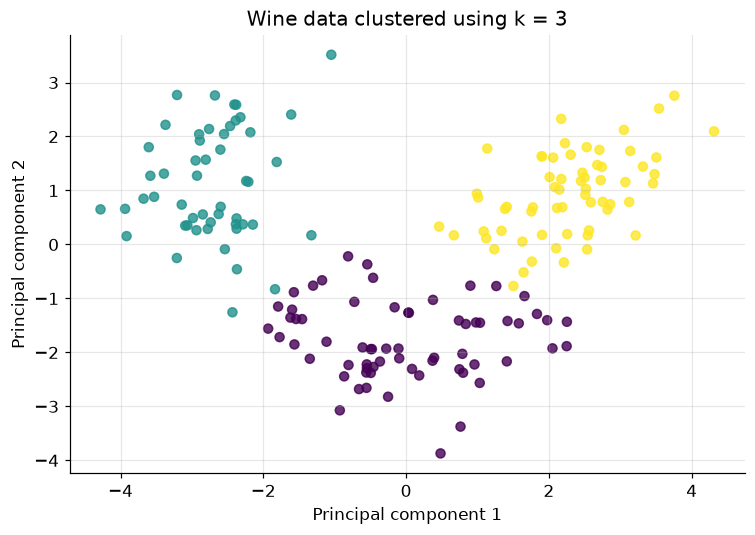

In [52]:
wine_pca = PCA(
    n_components=2,
    random_state=SEED
)

X_real_2d = wine_pca.fit_transform(X_real)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_real_2d[:, 0],
    X_real_2d[:, 1],
    c=wine_cluster_labels,
    cmap="viridis",
    s=35,
    alpha=0.8
)

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title(f"Wine data clustered using k = {my_k}")
plt.tight_layout()
plt.show()